In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier

# Data Cleaning


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ninzaami/loan-predication/train_u6lujuX_CVtuZ9i (1).csv")
# Check missing values
print("Missing Values Percentage")
print(df.isnull().mean()*100)
print(df.info())

Missing Values Percentage
Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-

In [3]:
# Numerical columns → use median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(),inplace=True)
# replacing the value of 3+ to 4
df = df.replace(to_replace='3+', value=3)
#convert Dependents to integer 
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').astype('Int64')
df['Dependents'].fillna(0, inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_55/3469260697.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_55/3469260697.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Exploratory Data Analysis

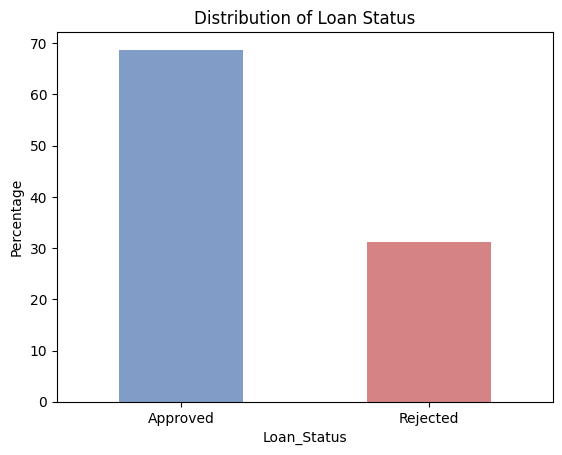

In [4]:
(df['Loan_Status'].value_counts(normalize=True)*100).plot(kind='bar',color=['#4C72B0', '#C44E52'],alpha=0.7)
plt.title('Distribution of Loan Status')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Approved', 'Rejected'], rotation=0) 
plt.show()

The dataset is mildly imbalanced, meaning we can't rely on accuracy alone
F1-score (especially for the Rejected class)
ROC-AUC
Precision-Recall for the minority class


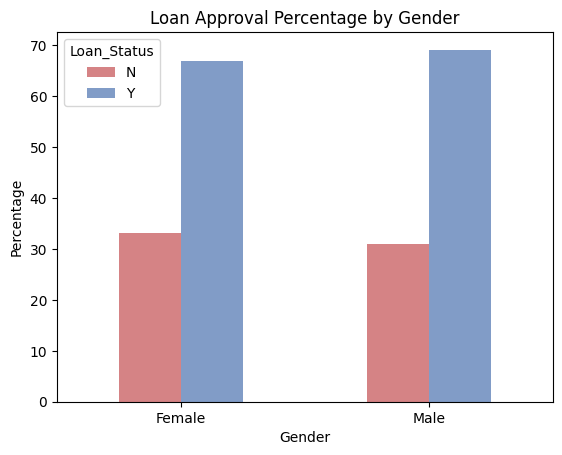

In [5]:
# Create a normalized crosstab and plot
gender_loan = pd.crosstab(df['Gender'], df['Loan_Status'], normalize='index') * 100
gender_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7)
plt.title('Loan Approval Percentage by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


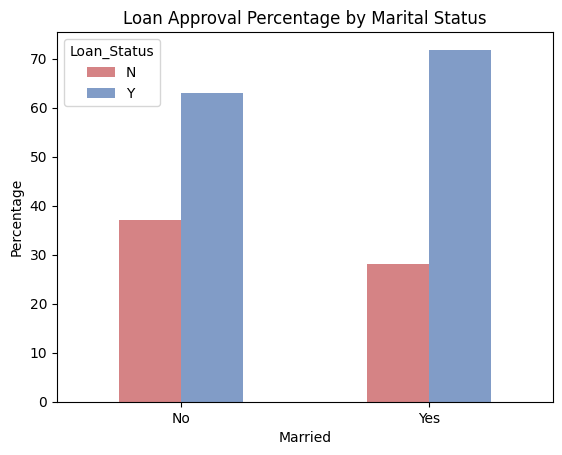

In [6]:
# Create a normalized crosstab and plot
marital_loan = pd.crosstab(df['Married'], df['Loan_Status'], normalize='index') * 100
marital_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7)
plt.title('Loan Approval Percentage by Marital Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


Married people have slightly more approvals rate than unmarried ones

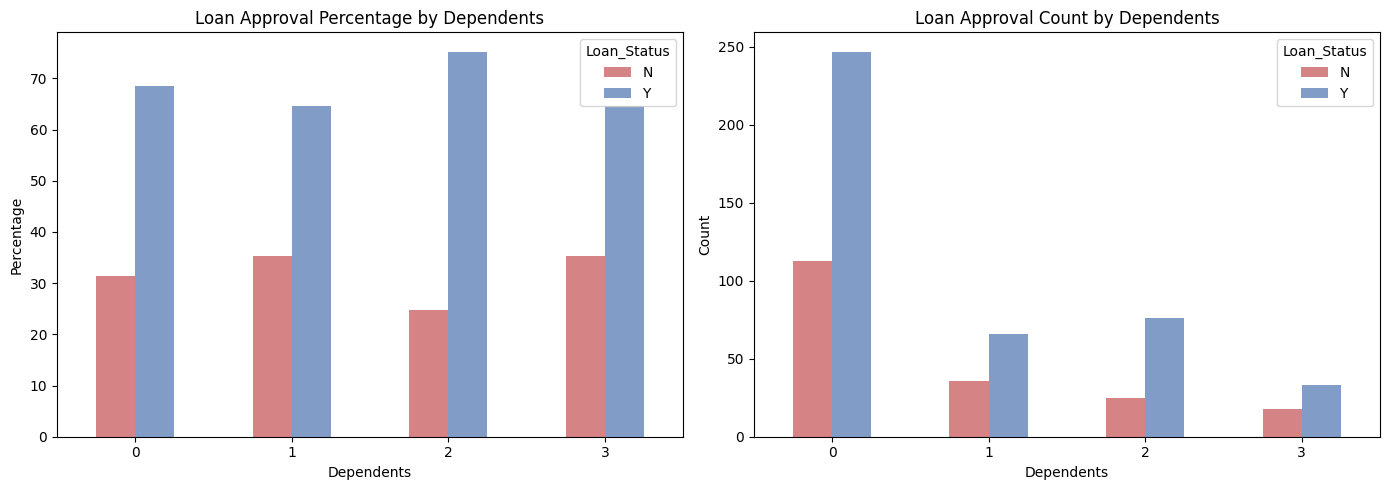

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentage (normalised)
dependent_loan = pd.crosstab(df['Dependents'], df['Loan_Status'], normalize='index') * 100
dependent_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[0])
axes[0].set_title('Loan Approval Percentage by Dependents')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Dependents')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Loan_Status')
# Count plot
dependent_count = pd.crosstab(df['Dependents'], df['Loan_Status'])
dependent_count.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[1])
axes[1].set_title('Loan Approval Count by Dependents')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Dependents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Loan_Status')

plt.tight_layout()
plt.show()

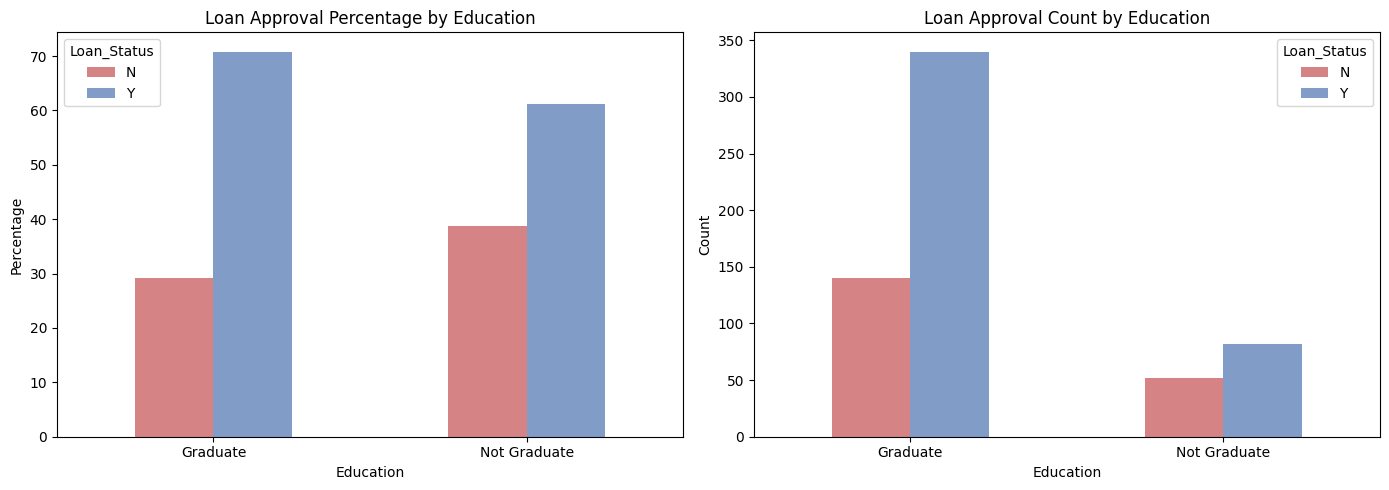

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Percentage (normalized) ---
educated_loan = pd.crosstab(df['Education'], df['Loan_Status'], normalize='index') * 100
educated_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[0])
axes[0].set_title('Loan Approval Percentage by Education')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Education')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Loan_Status')

# --- Plot 2: Count ---
educated_count = pd.crosstab(df['Education'], df['Loan_Status'])
educated_count.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[1])
axes[1].set_title('Loan Approval Count by Education')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Education')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Loan_Status')

plt.tight_layout()
plt.show()

 graduates have a ~10% higher approval rate. This is a useful feature.

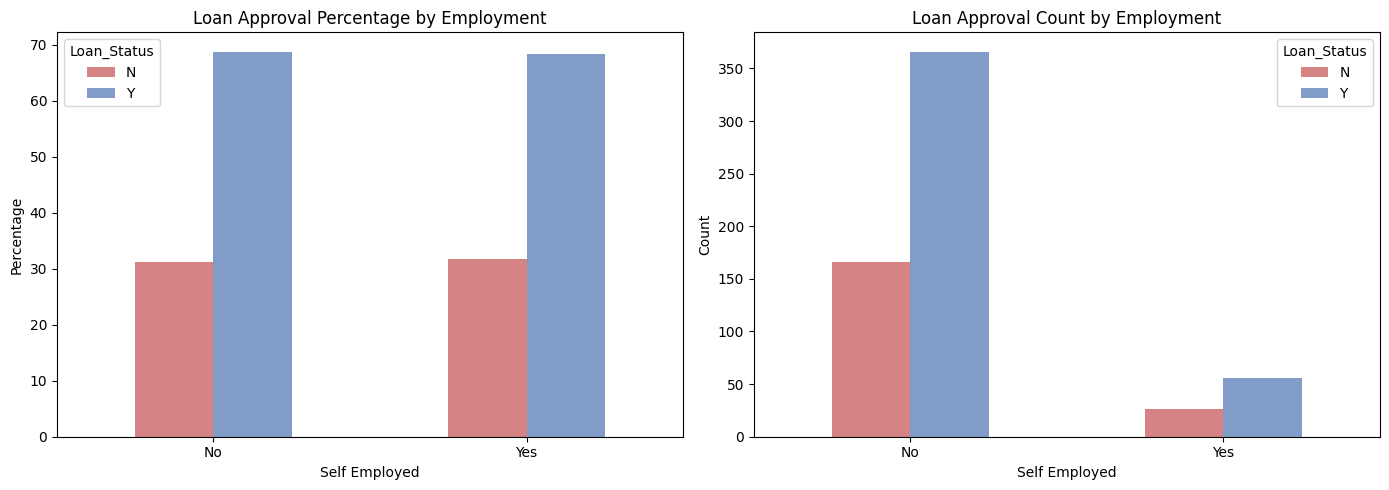

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Percentage (normalised)
em_loan = pd.crosstab(df['Self_Employed'], df['Loan_Status'], normalize='index') * 100
em_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[0])
axes[0].set_title('Loan Approval Percentage by Employment')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Self Employed')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Loan_Status')
# Count plot
em_count = pd.crosstab(df['Self_Employed'], df['Loan_Status'])
em_count.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[1])
axes[1].set_title('Loan Approval Count by Employment')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Self Employed')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Loan_Status')
plt.tight_layout()
plt.show()

Approval Rates are identical + Yes is highly underrepresented.so weak

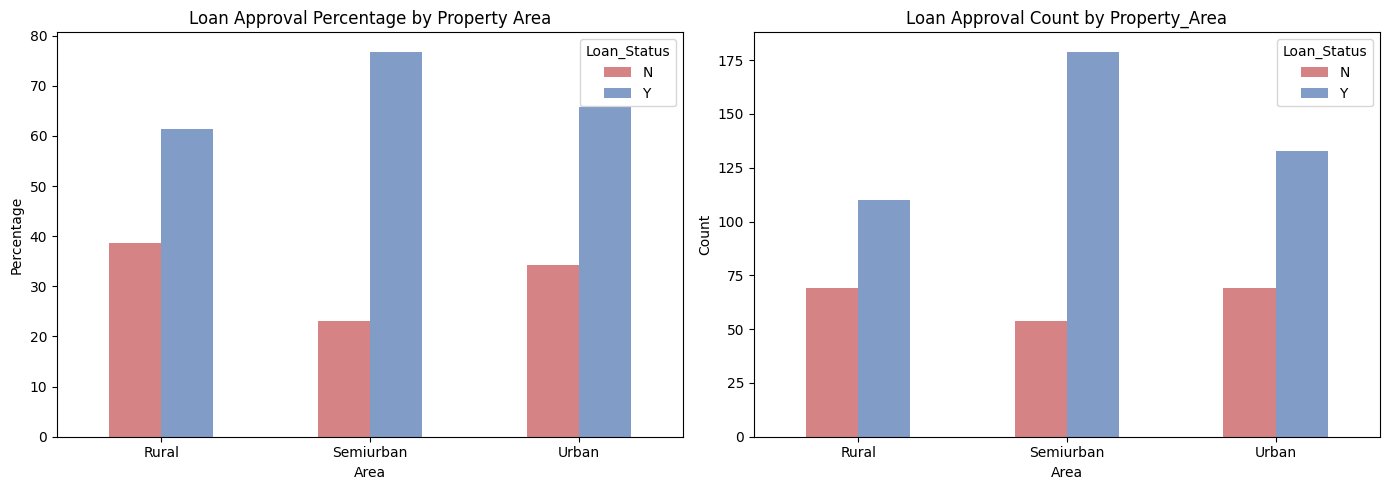

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Percentage (normalised)
p_loan = pd.crosstab(df['Property_Area'], df['Loan_Status'], normalize='index') * 100
p_loan.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[0])
axes[0].set_title('Loan Approval Percentage by Property Area')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Area')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Loan_Status')
# Count plot
p_count = pd.crosstab(df['Property_Area'], df['Loan_Status'])
p_count.plot(kind='bar', color=['#C44E52', '#4C72B0'], alpha=0.7, ax=axes[1])
axes[1].set_title('Loan Approval Count by Property_Area')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Area')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Loan_Status')
plt.tight_layout()
plt.show()

Semiurban applicants get approved at a significantly higher rate. 

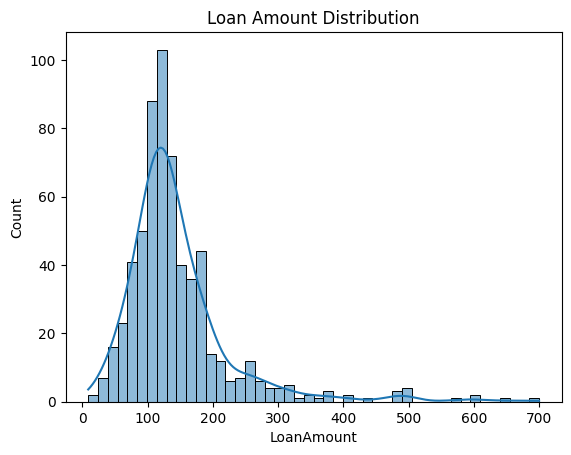

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loan Amount distribution
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()


/tmp/ipykernel_55/2781546202.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


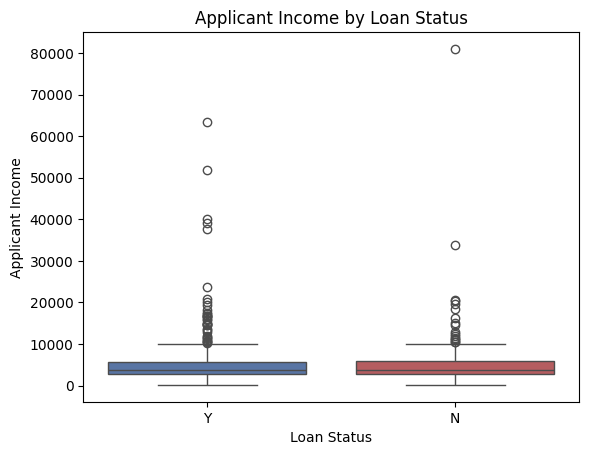

In [12]:
sns.boxplot(
    x='Loan_Status',
    y='ApplicantIncome',
    data=df,
    palette={'Y': '#4C72B0', 'N': '#C44E52'}
)
# Optional: Add titles and labels
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')

plt.show()

/tmp/ipykernel_55/3156281666.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


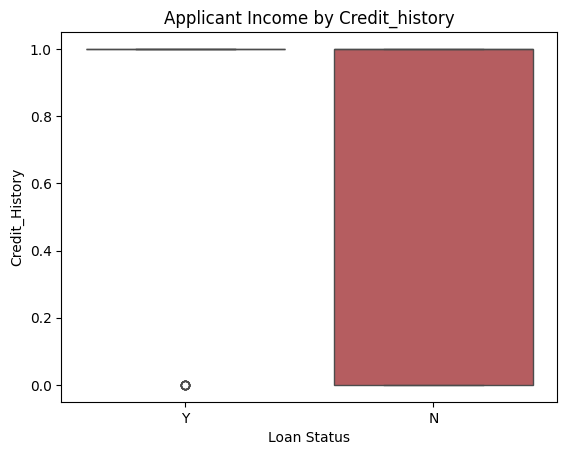

In [13]:
sns.boxplot(
    x='Loan_Status',
    y='Credit_History',
    data=df,
    palette={'Y': '#4C72B0', 'N': '#C44E52'}
)
# Optional: Add titles and labels
plt.title('Applicant Income by Credit_history')
plt.xlabel('Loan Status')
plt.ylabel('Credit_History')

plt.show()

Approved (Y): Almost everyone has Credit History = 1. The median, Q1, Q3 are all glued to 1.0. That single outlier dot at 0 is a rare exception.

Rejected (N): The entire box spans 0 to 1 — meaning rejections are spread across both good and bad credit history, but bad credit (0) is heavily represented.

In plain terms: good credit history doesn't guarantee approval, but bad credit history almost guarantees rejection.

/tmp/ipykernel_55/472969553.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


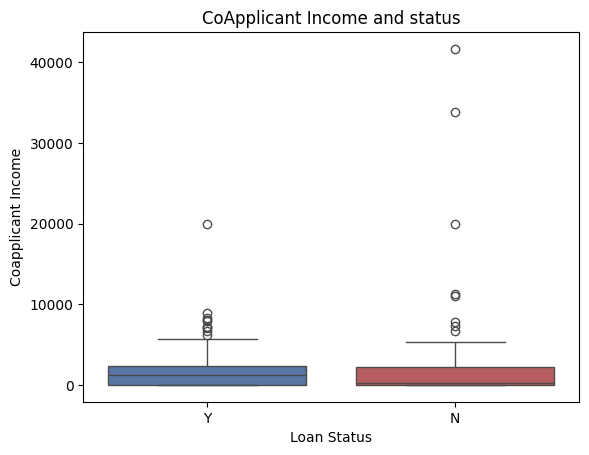

In [14]:
sns.boxplot(
    x='Loan_Status',
    y='CoapplicantIncome',
    data=df,
    palette={'Y': '#4C72B0', 'N': '#C44E52'}
)
plt.title('CoApplicant Income and status')
plt.xlabel('Loan Status')
plt.ylabel('Coapplicant Income')

plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    Int64  
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: Int64(1), float64(4), int64(1), object(7)
memory usage: 63.1+ KB


# Feature Engineering/Feature Selection

In [16]:
#drop column 
df.drop(columns=['Loan_ID'], inplace=True)

**Encode Categorical Column**

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Binary columns (Yes/No, Male/Female)
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']:
    df[col] = le.fit_transform(df[col])
# Ordinal - Property Area (use manual mapping to preserve order)
df['Property_Area'] = df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})

**Engineer Total Income + Log transforms**

In [18]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Total_Income_log'] = np.log1p(df['Total_Income'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

# Drop raw skewed columns
df.drop(columns=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term'], inplace=True)

In [19]:
        
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log
0,1,0,0,0,0,1.0,2,1,5849.0,8.674197,4.859812
1,1,1,1,0,0,1.0,0,0,6091.0,8.714732,4.859812
2,1,1,0,0,1,1.0,2,1,3000.0,8.006701,4.204693
3,1,1,0,1,0,1.0,2,1,4941.0,8.505525,4.795791
4,1,0,0,0,0,1.0,2,1,6000.0,8.699681,4.955827


# Modelling

In [20]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, never fit on test

In [22]:
# Baseline Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC: 0.823219814241486


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.48      0.55      0.51        38
           1       0.78      0.73      0.76        85

    accuracy                           0.67       123
   macro avg       0.63      0.64      0.63       123
weighted avg       0.69      0.67      0.68       123

ROC-AUC: 0.6410216718266253


In [24]:
dt_constrained = DecisionTreeClassifier(
    max_depth=4,          # don't grow too deep
    min_samples_leaf=10,  # each leaf needs 10+ samples
    class_weight='balanced',
    random_state=42
)
dt_constrained.fit(X_train_scaled, y_train)
y_pred_dtc = dt_constrained.predict(X_test_scaled)

print(classification_report(y_test, y_pred_dtc))
print("ROC-AUC:", roc_auc_score(y_test, dt_constrained.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.67      0.63      0.65        38
           1       0.84      0.86      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.75      0.75       123
weighted avg       0.79      0.79      0.79       123

ROC-AUC: 0.7662538699690402


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123

ROC-AUC: 0.8365325077399381


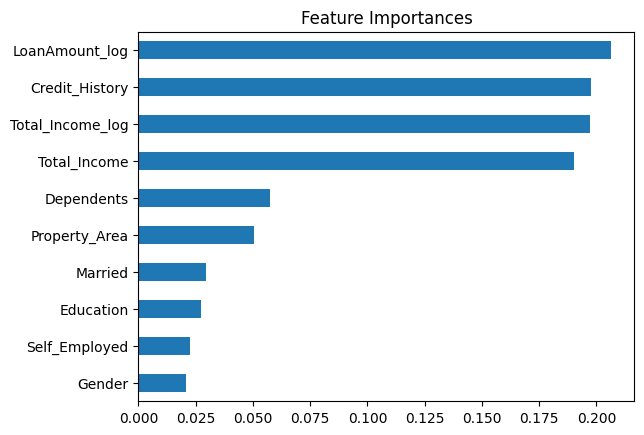

In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [28]:
xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=3,        # shallower trees
    learning_rate=0.1,
    subsample=0.8,      # use 80% of rows per tree
    colsample_bytree=0.8, # use 80% of features per tree
    random_state=42,
    eval_metric='auc'
)
xgb_tuned.fit(X_train_scaled, y_train)
y_pred_xgbt = xgb_tuned.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgbt))
print("ROC-AUC:", roc_auc_score(y_test, xgb_tuned.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.64      0.76      0.70        38
           1       0.88      0.81      0.85        85

    accuracy                           0.80       123
   macro avg       0.76      0.79      0.77       123
weighted avg       0.81      0.80      0.80       123

ROC-AUC: 0.8318885448916409


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr,
    'Decision Tree (constrained)': dt_constrained,
    'Random Forest': rf,
    'XGBoost (tuned)': xgb_tuned
}

print("Cross-Validation ROC-AUC Scores (5-fold)\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, 
                             cv=cv, scoring='roc_auc')
    print(f"{name}:")
    print(f"  Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
    print(f"  Scores: {scores.round(4)}\n")

Cross-Validation ROC-AUC Scores (5-fold)

Logistic Regression:
  Mean: 0.7088 | Std: 0.0813
  Scores: [0.7704 0.6887 0.7819 0.5595 0.7434]

Decision Tree (constrained):
  Mean: 0.6685 | Std: 0.0637
  Scores: [0.7054 0.6355 0.7366 0.5597 0.7053]

Random Forest:
  Mean: 0.7443 | Std: 0.0600
  Scores: [0.7891 0.725  0.7554 0.6399 0.812 ]

XGBoost (tuned):
  Mean: 0.7493 | Std: 0.0567
  Scores: [0.7491 0.7039 0.8209 0.6709 0.8016]

